In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from highlight_text import fig_text, ax_text
from PIL import Image

import requests
from bs4 import BeautifulSoup as bs
import urllib


In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import pandas as pd
import time

def get_data_selenium(url, table_name):
    options = Options()
    options.add_argument('--headless')  # Esegue senza aprire la finestra
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('user-agent=Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    
    driver = webdriver.Chrome(options=options)
    
    try:
        driver.get(url)
        print(f"Caricamento pagina: {url}")
        time.sleep(5)  # Aspetta il caricamento
        
        # Leggi il contenuto HTML
        html = driver.page_source
        df = pd.read_html(html)[table_name]
        df.columns = df.columns.droplevel()
        df = df[['Squad', 'MP', 'GF', 'GA', 'xG', 'xGA']]
        
        print("✓ Dati estratti con successo!")
        return df
    except Exception as e:
        print(f"✗ Errore: {e}")
        raise
    finally:
        driver.quit()

# URL da scaricare
urls = ['https://fbref.com/en/comps/11/Serie-A-Stats']

dfs = []
for url in urls:
    dfs.append(get_data_selenium(url, 1))
    time.sleep(3)
    
pd.concat(dfs).to_csv('serieAfbref.csv', sep=',', encoding='utf-8-sig', index=False)
print("File CSV salvato!")

Caricamento pagina: https://fbref.com/en/comps/11/Serie-A-Stats


/var/folders/4j/0qhwz1ys4pj2n7gvzw99zzd00000gn/T/ipykernel_2024/3840451876.py:23: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[table_name]


✓ Dati estratti con successo!
File CSV salvato!


In [3]:
def prediction(data1, team_home = "Atalanta", team_away = "Lecce"):

    data1.columns = ['team', 'MPH', 'MPA', 'GFH', 'GFA', 'GAH', 'GAA', 'xGH', 'xGA', 'xGAH', 'xGAA']
    df2 = pd.read_csv("My_serieA_rating.csv")
    df3 = pd.read_csv("Loghi_SerieA.csv")

    data_merged = pd.merge(data1, df2, on='team')
    data = pd.merge(data_merged, df3, on='team')
    
    #constant
    average_xG_h = data['xGH'].sum()/data['MPH'].sum()
    average_xGA_h = data['xGAH'].sum()/data['MPH'].sum()
    average_xG_a = data['xGA'].sum()/data['MPA'].sum()
    average_xGA_a = data['xGAA'].sum()/data['MPA'].sum()
    
    average_GF_h = data['GFH'].sum()/data['MPH'].sum()
    average_GA_h = data['GAH'].sum()/data['MPH'].sum()
    average_GF_a = data['GFA'].sum()/data['MPA'].sum()
    average_GA_a = data['GAA'].sum()/data['MPA'].sum()
    
    # -- Filter the data from our DF
    team_df_h = data[data["team"] == team_home].reset_index(drop = True)
    team_df_a = data[data["team"] == team_away].reset_index(drop = True)
            
    #home_id = team_df_h.at[0, 'team_id']
    #away_id = team_df_a.at[0, 'team_id']
    
    home_attack = ((team_df_h["xGH"]/team_df_h['MPH'])/average_xG_h + (team_df_h["GFH"]/team_df_h['MPH'])/average_GF_h)/2
    home_defense = ((team_df_h["xGAH"]/team_df_h['MPH'])/average_xGA_h + (team_df_h["GAH"]/team_df_h['MPH'])/average_GA_h)/2
    away_attack = ((team_df_a["xGA"]/team_df_a['MPA'])/average_xG_a + (team_df_a["GFA"]/team_df_a['MPA'])/average_GF_a)/2
    away_defense = ((team_df_a["xGAA"]/team_df_a['MPA'])/average_xGA_a + (team_df_a["GAA"]/team_df_a['MPA'])/average_GA_a)/2
    
    projected_h_g = home_attack*away_defense*average_xG_h*average_GF_h*1.03
    projected_a_g = away_attack*home_defense*average_xG_a*average_GF_a*0.97
    
    if (team_df_h.at[0, "spi"] <= team_df_a.at[0, "spi"]):
        diff_pi = (team_df_a["spi"]-team_df_h["spi"])/200
        projected_h_g = projected_h_g*(1-diff_pi)
        projected_a_g = projected_a_g*(1+diff_pi)
        
    else:
        diff_pi = (team_df_h["spi"]-team_df_a["spi"])/200
        projected_h_g = projected_h_g*(1+diff_pi)
        projected_a_g = projected_a_g*(1-diff_pi)
        
    projected_tot_g = projected_h_g+projected_a_g
    
    h_goals = []
    a_goals = []
    
    table = np.zeros((9,9), float)
       
    h = [8, 7, 6, 5, 4, 3, 2, 1, 0]
    a = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    
    for i in range (len(h)):
        h_goals = np.append(h_goals, (((projected_a_g**i)*np.exp(-projected_a_g))/math.factorial(i)).astype(float))
        
    for i in range (len(a)):
        a_goals = np.append(a_goals, (((projected_h_g**i)*np.exp(-projected_h_g))/math.factorial(i)).astype(float))
    
    for i in range (len(h)):
        for j in range (len(a)):
            table[i,j] = h_goals[i]*a_goals[j]*100
    
    return table

In [4]:
def battery_plot(win, draw, lose,  ax):
    '''
    This function takes an integer and an axes and 
    plots a battery chart.
    '''
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.barh([0.5], [1], fc = 'white', ec='black', height=.35)
    ax.barh([0.5], [win/100], fc = '#de6f57', ec='black',
            hatch='//////', height=.35, zorder=2)
    ax.barh([0.5], [draw/100], left=[win/100], fc = 'grey', ec='black',
            hatch='//////', height=.35, zorder=2)
    ax.barh([0.5], [lose/100], left=[win/100+draw/100], fc = '#287271', ec='black', 
            hatch='//////', height=.35, zorder=2)

    text_ = ax.annotate(
        xy=((win/100)/2, .9),
        text=f'{win/100:.1%}',
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=10
    )
    
    text_ = ax.annotate(
        xy=((win/100)+(draw/100)/2, .9),
        text=f'{draw/100:.1%}',
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=10
    )
    
    text_ = ax.annotate(
        xy=((win/100)+(draw/100)+(lose/100)/2, .9),
        text=f'{lose/100:.1%}',
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=10
    )
    
    ax.set_axis_off()
    return ax

In [5]:
def bar_plot_p(goal, no_goal, label, ax):
    
    ax.set_xlim(0, 0.6)
    ax.set_ylim(-6, 90)
    b1 = ax.bar(x=0.2, height=goal, width=0.1, color='#de6f57', 
            hatch='//////', ec='black', linewidth=1.)
    ax.bar_label(b1, labels=[str(goal)+'%'], weight='bold', padding=0)
    b2 = ax.bar(x=0.4, height=no_goal, width=0.1, color='#287271', 
            hatch='//////', ec='black', linewidth=1.)
    ax.bar_label(b2, labels=[str(no_goal)+'%'], weight='bold', padding=0)

    text_ = ax.annotate(
        xy=(0.21, -6),
        text=label[0],
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=12
    )
    
    text_ = ax.annotate(
        xy=(0.41, -6),
        text=label[1],
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=12
    )
    
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0,0], color='black', lw=.75, zorder=3)
    
    ax.set_axis_off()
    return ax

In [6]:
def bar_plot(goal, no_goal, label, ax):
    
    ax.set_xlim(0, 0.6)
    ax.set_ylim(-0.2, 3)
    b1 = ax.bar(x=0.2, height=goal, width=0.1, color='#de6f57', 
            hatch='//////', ec='black', linewidth=1.)
    ax.bar_label(b1, labels=[str(goal)], weight='bold', padding=0)
    
    b2 = ax.bar(x=0.4, height=no_goal, width=0.1, color='#287271', 
            hatch='//////', ec='black', linewidth=1.)
    ax.bar_label(b2, labels=[str(no_goal)], weight='bold', padding=0)

    text_ = ax.annotate(
        xy=(0.21, -0.2),
        text=label[0],
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=12
    )
    
    text_ = ax.annotate(
        xy=(0.41, -0.2),
        text=label[1],
        xytext=(-8,0),
        textcoords='offset points',
        weight='bold',
        color='black',
        va='center',
        ha='center',
        size=12
    )
    
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0,0], color='black', lw=.75, zorder=3)
    
    ax.set_axis_off()
    return ax

In [7]:
def table_plot(table, home, away, ax):
    
    # Ottieni le dimensioni della tabella
    rows, cols = table.shape
    
    ax.imshow(table, alpha=0.8, cmap="YlGn", aspect=0.2, interpolation='antialiased', 
              vmin=0, vmax=16, origin="lower")    
    
    # Imposta il colore di sfondo
    ax.set_facecolor("#EFE9E6")
    
    min_val, max_val, diff = 0, cols, 1    
    ax.set_xticks(np.arange(min_val, max_val))
    ax.set_yticks(np.arange(min_val, max_val))
    ax.set_xticklabels(range(cols))
    ax.set_yticklabels(range(rows))
    ax.set_xlim(min_val-diff/2, max_val-diff/2)
    ax.set_ylim(min_val-diff/2, max_val-diff/2)
    
    # MOSTRA TUTTI I BORDI con lo stesso stile
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)
    
    # Add axes legends
    ax.yaxis.set_label_text("{} goals".format(away), size=10, fontweight='bold')
    ax.xaxis.set_label_text("{} goals".format(home), size=10, fontweight='bold')
    
    # Aggiungi griglia leggera (opzionale)
    ax.grid(True, which='major', axis='both', linestyle='-', color='white', 
            linewidth=0.5, alpha=0.3)

    # Ciclo dinamico basato sulle dimensioni della tabella
    for i in range(rows):
        for j in range(cols):
            c = table[i][j]
            ax.text(j, i, str(round(c, 1))+"%", va='center', ha='center', 
                    size=8, fontweight='bold')
    
    return ax

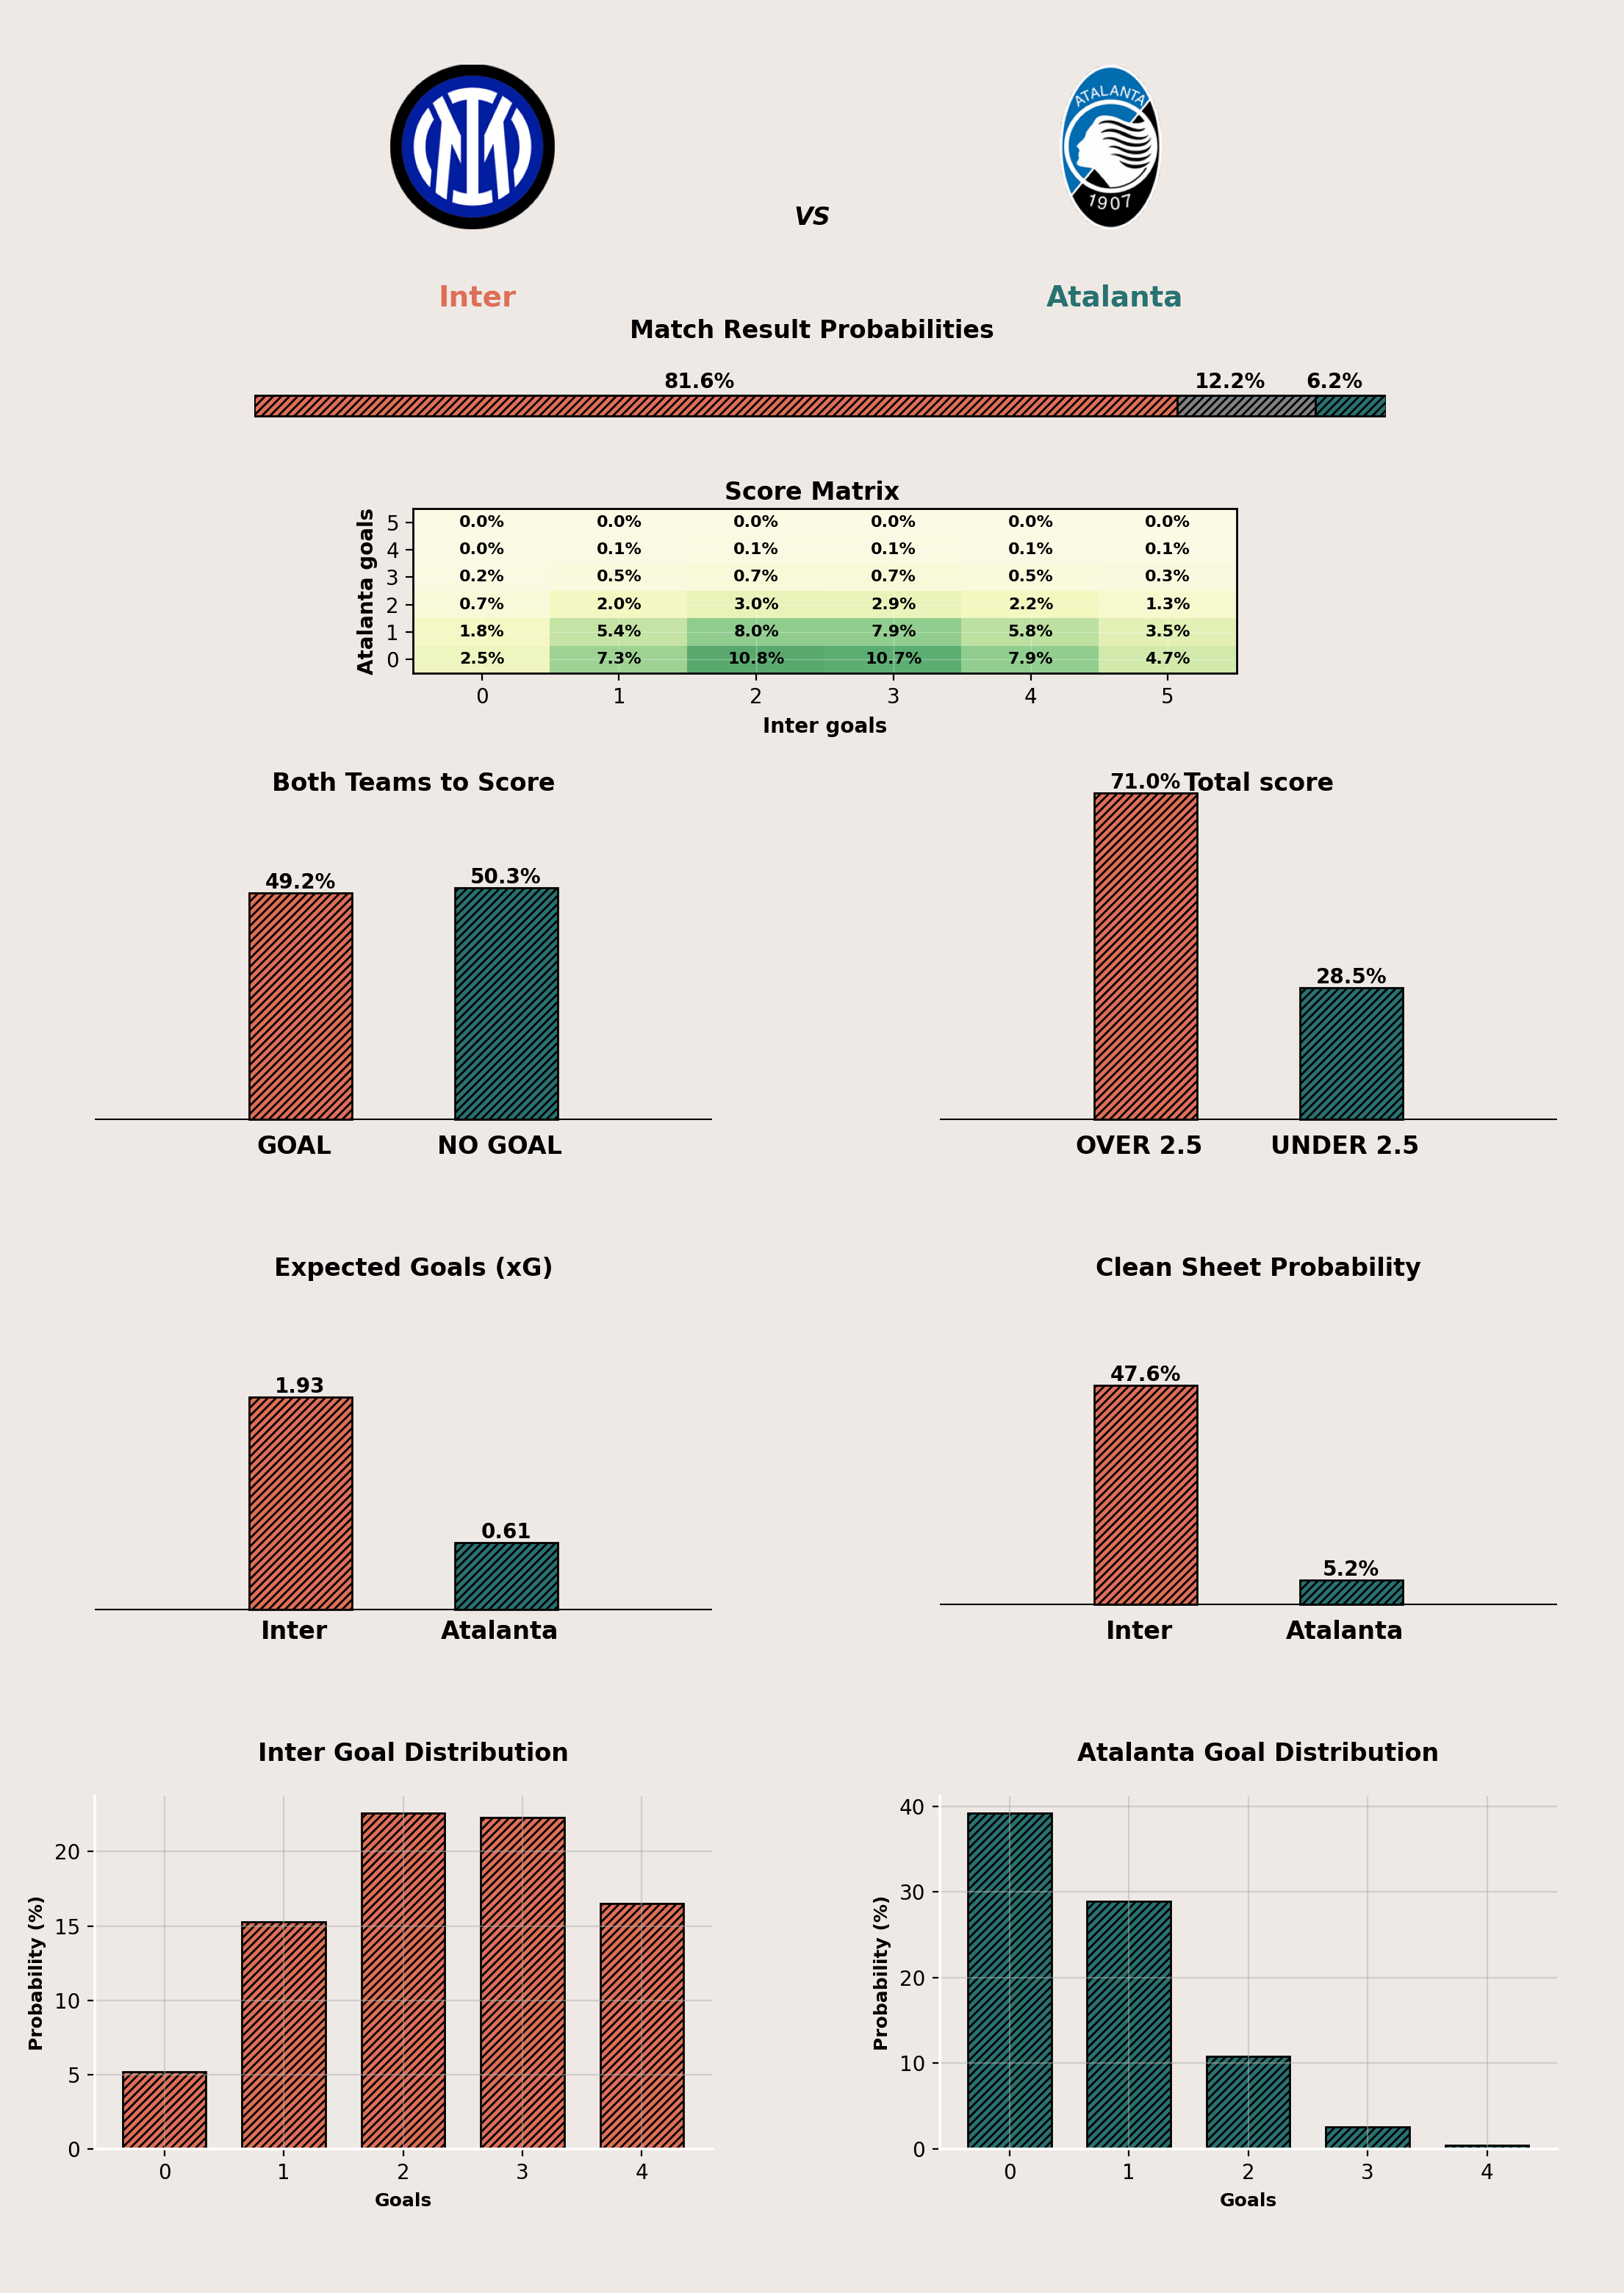

In [19]:
# Carica i dati e fai la predizione
home = 'Inter'   
away = 'Atalanta'
df = pd.read_csv("serieAfbref.csv")
df['Squad'] = df['Squad'].str.replace('Hellas Verona','Verona')

# Ottieni predizione
table = prediction(data1=df, team_home=home, team_away=away)
[m, n] = np.shape(table)

# Merge con i loghi
df1 = pd.read_csv("My_serieA_rating.csv")
dfl = pd.read_csv('Loghi_SerieA.csv')
df_logos = pd.merge(df1, dfl, on='team')
    
# Calcola tutte le statistiche
win = 0
draw = 0
lose = 0
for i in range(m):
    for j in range(n):
        c = table[i][j]
        if (i==j):
            draw = round(draw+c, 1)
        elif (i>j):
            lose = round(lose+c, 1)
        else:
            win = round(win+c, 1)
if (win+draw+lose == 100):
    pass
else:
    total = win+draw+lose
    draw = draw + (100-total)

goal = 0
no_goal = 0
for i in range(m):
    for j in range(n):
        c = table[i][j]
        if (i==0 or j==0):
            no_goal = round(no_goal+c, 1)
        else:
            goal = round(goal+c, 1)   

over25 = 0
under25 = 0
for i in range(m):
    for j in range(n):
        c = table[i][j]
        if (i+j>2.5):
            over25 = round(over25+c, 1)
        else:
            under25 = round(under25+c, 1)   

goal_home = np.zeros(9, float)
xg_home = 0
for i in range(5):
    for j in range(5):
        c = table[j][i]
        goal_home[i] = round(goal_home[i] + c, 1)
    xg_home = round(xg_home + goal_home[i]/100*i, 2)
    
goal_away = np.zeros(9, float)
xg_away = 0
for i in range(5):
    for j in range(5):
        c = table[i][j]
        goal_away[i] = round(goal_away[i] + c, 1)
    xg_away = round(xg_away + goal_away[i]/100*i, 2)

cs_home = 0
cs_away = 0
for i in range(m):
    for j in range(n):
        c = table[i][j]
        if (i==0):
            cs_home = round(cs_home+c, 1)
        if (j==0):
            cs_away = round(cs_away+c, 1)

# ========== VISUALIZZAZIONE ==========

fig = plt.figure(figsize=(14, 20), dpi=200, facecolor='#EFE9E6')
ax = plt.subplot(111, facecolor="#EFE9E6")

ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

# --- Define URL and helper functions to add logos
fotmob_url = 'https://images.fotmob.com/image_resources/logo/teamlogo/'
DC_to_FC = ax.transData.transform
FC_to_NFC = fig.transFigure.inverted().transform
DC_to_NFC = lambda x: FC_to_NFC(DC_to_FC(x))

# Get team IDs
home_id = df_logos[df_logos['team'] == home]['team_id'].values[0]
away_id = df_logos[df_logos['team'] == away]['team_id'].values[0]

# ========== ROW 1: STEMMI E NOMI SQUADRE ==========
y = 13

# Logo e nome squadra di casa (sinistra)
try:
    ax_coords = DC_to_NFC([3, y])
    logo_ax = fig.add_axes([ax_coords[0]-0.05, ax_coords[1]-0.03, 0.08, 0.08], anchor="C")
    club_icon = Image.open(urllib.request.urlopen(f"{fotmob_url}{home_id}.png"))
    logo_ax.imshow(club_icon)
    logo_ax.axis("off")
except Exception as e:
    print(f"Logo {home} non caricato: {e}")

ax.text(2.9, y - 0.8, home, fontsize=14, fontweight='bold', ha='center', color='#de6f57')

# VS centrale
ax.text(5, y - 0.3, 'VS', fontsize=12, fontweight='bold', ha='center', color='black', style='italic')

# Logo e nome squadra in trasferta (destra)
try:
    ax_coords = DC_to_NFC([7, y])
    logo_ax = fig.add_axes([ax_coords[0]-0.05, ax_coords[1]-0.03, 0.08, 0.08], anchor="C")
    club_icon = Image.open(urllib.request.urlopen(f"{fotmob_url}{away_id}.png"))
    logo_ax.imshow(club_icon)
    logo_ax.axis("off")
except Exception as e:
    print(f"Logo {away} non caricato: {e}")

ax.text(6.9, y - 0.8, away, fontsize=14, fontweight='bold', ha='center', color='#287271')

# ========== ROW 2: BATTERY PLOT 1X2 (PIÙ SOTTILE) ==========
y = 12

ax.text(5, y, 'Match Result Probabilities', fontsize=12, fontweight='bold', ha='center')

# Battery plot più sottile
ax_coords = DC_to_NFC([1.5, y-0.6])
battery_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.55, 0.02])
battery_plot(win, draw, lose, battery_ax)

# ========== ROW 3: TABELLA MATRICE CENTRATA ==========
y = 11

ax.text(5, y , 'Score Matrix', fontsize=12, fontweight='bold', ha='center')

# Tabella centrata e più grande
ax_coords = DC_to_NFC([2.5, y-4.2])
table_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.4, 0.4])
table_plot(table[:6, :6], home, away, table_ax)

# ========== ROW 4: Goal/No Goal + Over/Under ==========
y = 8

ax.text(2.5, y+1.2, 'Both Teams to Score', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([0.5, y-1])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.15])
bar_plot_p(goal, no_goal, ['GOAL', 'NO GOAL'], plot_ax)

ax.text(7.8, y+1.2, 'Total score', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([5.8, y-1])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.15])
bar_plot_p(over25, under25, ['OVER 2.5', 'UNDER 2.5'], plot_ax)

# ========== ROW 5: Expected Goals + Clean Sheets ==========
y = 5

ax.text(2.5, y+1.2, 'Expected Goals (xG)', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([0.5, y-1])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.12])
bar_plot(xg_home, xg_away, [home, away], plot_ax)

ax.text(7.8, y+1.2, 'Clean Sheet Probability', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([5.8, y-1])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.15])
bar_plot_p(cs_home, cs_away, [f'{home}', f'{away}'], plot_ax)

# ========== ROW 6: Distribuzione gol casa + trasferta ==========
y = 2

ax.text(2.5, y+1.2, f'{home} Goal Distribution', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([0.5, y-1.2])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.12])
plot_ax.bar(range(5), goal_home[:5], color='#de6f57', hatch='//////', ec='black', linewidth=1., width=0.7)
plot_ax.set_facecolor("#EFE9E6")
plot_ax.set_xlabel('Goals', fontsize=9, fontweight='bold')
plot_ax.set_ylabel('Probability (%)', fontsize=9, fontweight='bold')
plot_ax.set_xticks(range(5))
plot_ax.grid(axis='y', alpha=0.5)
plot_ax.grid(axis='x', alpha=0.5)
plot_ax.spines['top'].set_visible(False)      # Nascondi bordo superiore
plot_ax.spines['right'].set_visible(False)    # Nascondi bordo destro
plot_ax.spines['left'].set_visible(True)      # MOSTRA bordo sinistro
plot_ax.spines['bottom'].set_visible(True)    # MOSTRA bordo sotto
plot_ax.spines['left'].set_color('white')     # Colore nero
plot_ax.spines['bottom'].set_color('white')   # Colore nero
plot_ax.spines['left'].set_linewidth(1.3)     # Spessore
plot_ax.spines['bottom'].set_linewidth(1.3)   # Spessore

ax.text(7.8, y+1.2, f'{away} Goal Distribution', fontsize=12, fontweight='bold', ha='center')
ax_coords = DC_to_NFC([5.8, y-1.2])
plot_ax = fig.add_axes([ax_coords[0], ax_coords[1], 0.3, 0.12])
plot_ax.bar(range(5), goal_away[:5], color='#287271', hatch='//////', ec='black', linewidth=1., width=0.7)
plot_ax.set_facecolor("#EFE9E6")
plot_ax.set_xlabel('Goals', fontsize=9, fontweight='bold')
plot_ax.set_ylabel('Probability (%)', fontsize=9, fontweight='bold')
plot_ax.set_xticks(range(5))
plot_ax.grid(axis='y', alpha=0.5)
plot_ax.grid(axis='x', alpha=0.5)
plot_ax.spines['top'].set_visible(False)      # Nascondi bordo superiore
plot_ax.spines['right'].set_visible(False)    # Nascondi bordo destro
plot_ax.spines['left'].set_visible(True)      # MOSTRA bordo sinistro
plot_ax.spines['bottom'].set_visible(True)    # MOSTRA bordo sotto
plot_ax.spines['left'].set_color('white')     # Colore nero
plot_ax.spines['bottom'].set_color('white')   # Colore nero
plot_ax.spines['left'].set_linewidth(1.3)     # Spessore
plot_ax.spines['bottom'].set_linewidth(1.3)   # Spessore

plt.show()